### **Exploratory Data Analysis – V-features vs Class**

#### 1. Focus on V-features + Target
- Selected only **V1–V28** and `Class` for correlation analysis.  
- Computed correlation matrix to assess feature relationships.  

#### 2. Correlation with Class
- Extracted correlations of each V-feature with `Class`.  
- Most features show weak correlation (expected from PCA transformation).  
- **Top correlated features with Class:**  
  - `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, `V18`  
- These features are likely to be the **most predictive** in fraud detection.  

#### 3. Correlation Heatmap
- Heatmap of V-features + `Class`.  
- Features appear **largely uncorrelated with each other**, avoiding multicollinearity issues.  
- A few features stand out with stronger alignment to `Class`.  

#### 4. Distribution of Top Features
- Violin plots show **feature distribution differences** between fraud (`Class=1`) and non-fraud (`Class=0`).  
- Fraudulent transactions often exhibit **wider or shifted distributions** in features like `V17`, `V14`, `V12`, `V10`, `V16`.  
- Some features (e.g., `V4`, `V18`) show subtler but noticeable separation.  

---

### **Key Takeaways**
- Although individual correlations are modest, certain V-features provide **valuable separation** between fraud and legitimate transactions.  
- These features should be prioritized in **model training and feature importance analysis**.  
- Overall, V-features capture hidden structure from PCA and remain central to fraud detection modeling.  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline


In [2]:
# Install Kaggle API client
!pip install kaggle

# Make a directory for Kaggle and move the kaggle.json file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
# The dataset URL from the problem statement is: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Unzip the downloaded file
!unzip creditcardfraud.zip

# Load the dataset into a pandas DataFrame
df = pd.read_csv('creditcard.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:03<00:00, 18.1MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
First 5 rows of the dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.1

In [3]:
# Extract Hour from Time (convert seconds → hours)
df["Hour"] = (df["Time"] // 3600) % 24

# Log-transform Amount
df["Amount_log"] = np.log1p(df["Amount"])

# Drop original Time column (redundant now)
df = df.drop(columns=["Time"])

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,Amount_log
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,5.939276
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,4.824306
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,4.262539


In [4]:
# Focus only on V-features + Class
v_features = [col for col in df.columns if col.startswith("V")] + ["Class"]

corr_matrix = df[v_features].corr()
corr_matrix

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
V1,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,7.388135e-17,...,4.654551e-16,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.101347
V2,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,-3.991394e-16,...,2.506675e-16,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,0.091289
V3,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,1.156587e-15,...,-9.316409e-16,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.192961
V4,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,2.232685e-16,...,-1.857247e-16,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.133447
V5,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,-5.202306e-16,...,-3.554057e-16,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.094974
V6,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,5.932243e-17,...,-1.858755e-16,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,-0.043643
V7,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,-7.492834e-17,...,9.379684e-16,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,-0.187257
V8,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,-2.801370e-16,...,2.033737e-16,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,0.019875
V9,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,-4.642274e-16,...,-2.343720e-16,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.097733
V10,7.388135e-17,-3.991394e-16,1.156587e-15,2.232685e-16,-5.202306e-16,5.932243e-17,-7.492834e-17,-2.801370e-16,-4.642274e-16,1.000000e+00,...,-1.331556e-15,1.177547e-15,-6.418202e-16,3.214491e-16,-1.355885e-16,-2.846052e-16,-3.028119e-16,-2.197977e-16,4.864782e-17,-0.216883


In [5]:
# Display correlation of each feature with Class
corr_with_class = corr_matrix["Class"].drop("Class").sort_values(key=np.abs, ascending=False)
corr_with_class.head(15)

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


### Correlation with Target
- Selected only **V-features** along with `Class`.  
- Computed correlation matrix.  
- Sorted correlations of features with `Class` (top 15 shown).  

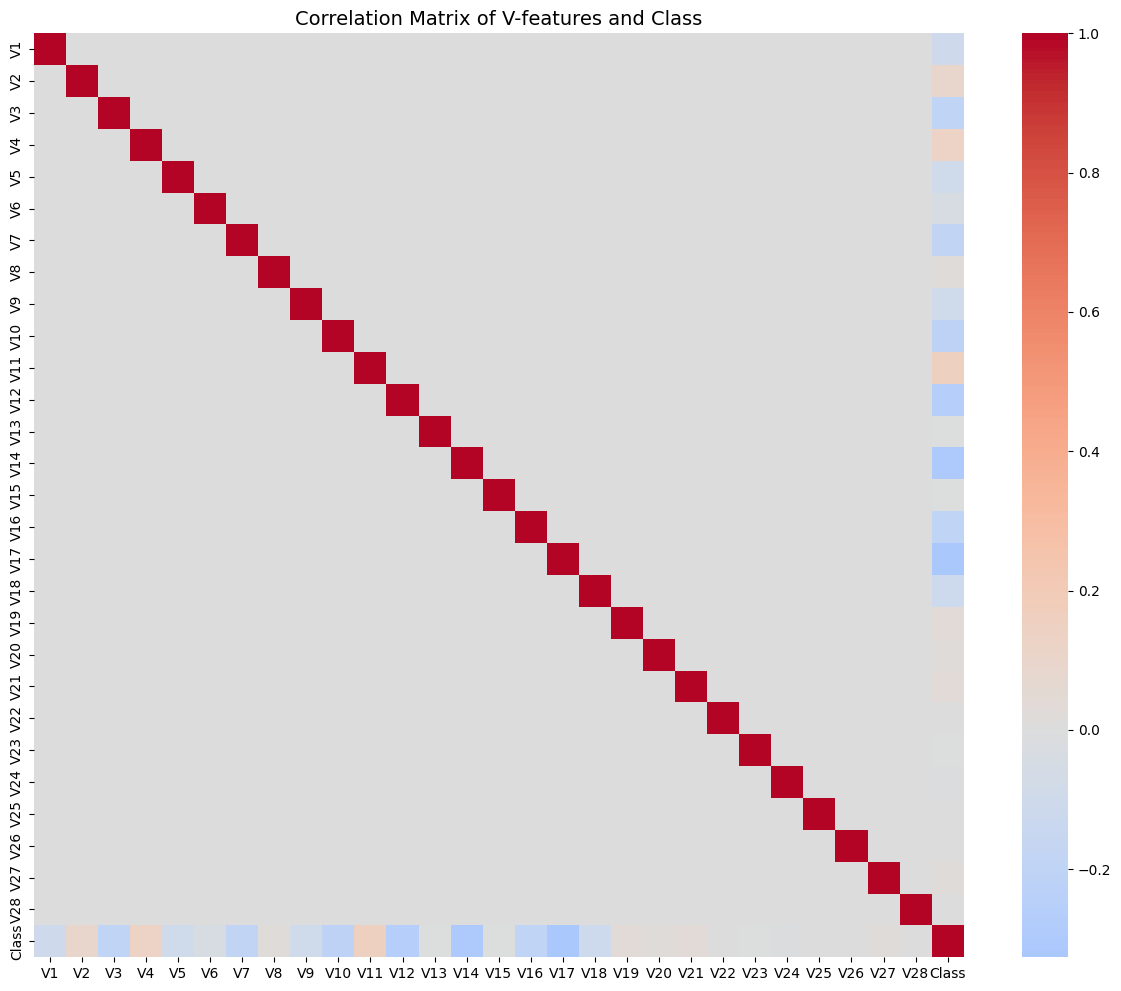

In [6]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, cbar=True)
plt.title("Correlation Matrix of V-features and Class", fontsize=14)
plt.show()

In [7]:
top_features = corr_with_class.head(10).index.tolist()
print("Top correlated features with Class:\n", top_features)

Top correlated features with Class:
 ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']


### Correlation Matrix of V-features and Class
- Computed correlations of V1–V28 with the target `Class`.  
- Most features show **weak correlation** (expected from PCA transformation).  
- Some features stand out with stronger correlations to fraud.  

**Top correlated features with Class:**  
- `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, `V18`  

👉 These features may carry the **most predictive power** for fraud detection and are good candidates for further analysis/modeling.  

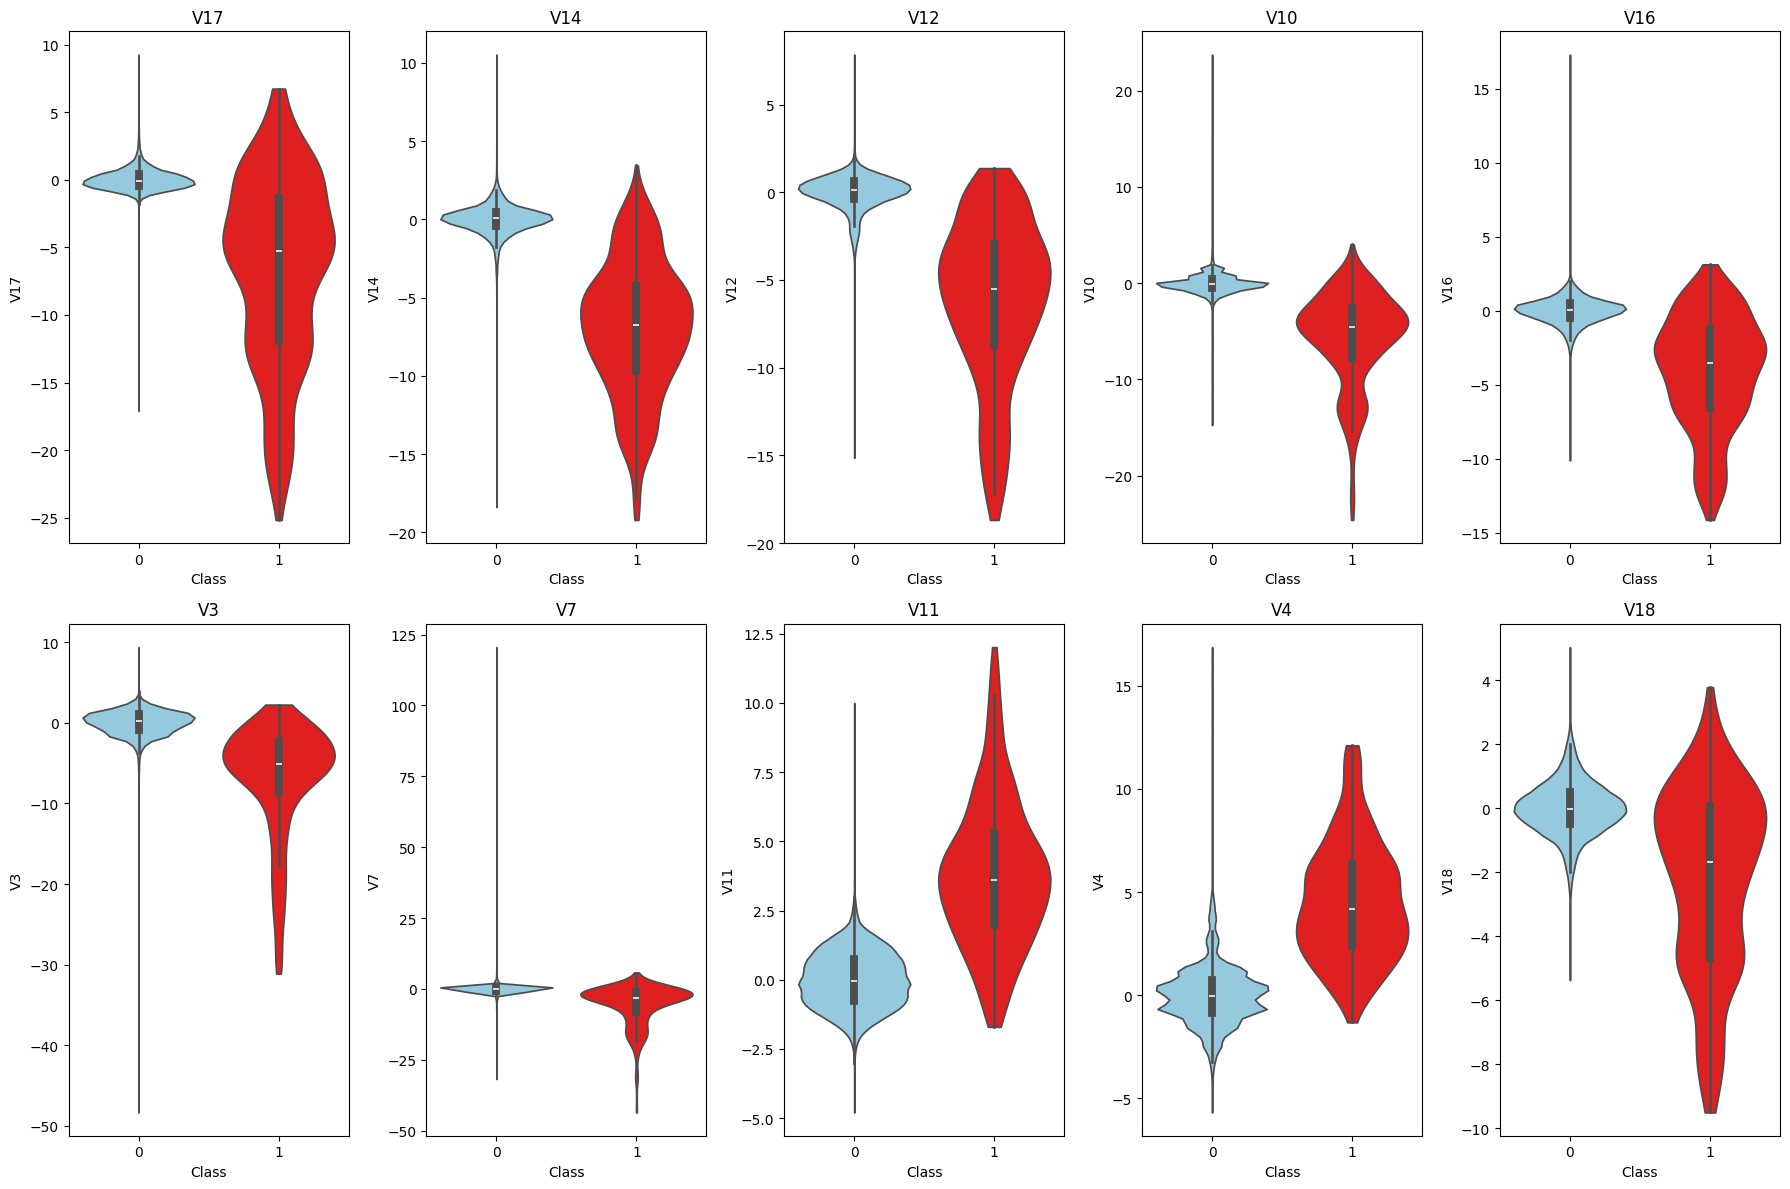

In [9]:
import os

# Create the directory if it doesn't exist
output_dir = "../reports/figures/"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(18, 12))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 5, i)
    sns.violinplot(
        x="Class",
        y=feature,
        hue="Class",
        data=df,
        palette={0: "skyblue", 1: "red"},
        cut=0,
        density_norm="width",
        legend=False
    )
    plt.title(feature)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top_vfeatures_violin.png"), bbox_inches="tight")
plt.show()

In [11]:
print("Summary Statistics for Top Correlated Features:")
display(df[top_features + ['Class']].describe())

Summary Statistics for Top Correlated Features:


,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,Class
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,-3.772171e-16,1.207294e-15,-1.247012e-15,2.239053e-15,1.437716e-15,-1.379537e-15,-5.556467e-16,1.673327e-15,2.074095e-15,9.564149e-16,0.001727
std,8.493371e-01,9.585956e-01,9.992014e-01,1.088850e+00,8.762529e-01,1.516255e+00,1.237094e+00,1.020713e+00,1.415869e+00,8.381762e-01,0.041527
min,-2.516280e+01,-1.921433e+01,-1.868371e+01,-2.458826e+01,-1.412985e+01,-4.832559e+01,-4.355724e+01,-4.797473e+00,-5.683171e+00,-9.498746e+00,0.000000
25%,-4.837483e-01,-4.255740e-01,-4.055715e-01,-5.354257e-01,-4.680368e-01,-8.903648e-01,-5.540759e-01,-7.624942e-01,-8.486401e-01,-4.988498e-01,0.000000
50%,-6.567575e-02,5.060132e-02,1.400326e-01,-9.291738e-02,6.641332e-02,1.798463e-01,4.010308e-02,-3.275735e-02,-1.984653e-02,-3.636312e-03,0.000000
75%,3.996750e-01,4.931498e-01,6.182380e-01,4.539234e-01,5.232963e-01,1.027196e+00,5.704361e-01,7.395934e-01,7.433413e-01,5.008067e-01,0.000000
max,9.253526e+00,1.052677e+01,7.848392e+00,2.374514e+01,1.731511e+01,9.382558e+00,1.205895e+02,1.201891e+01,1.687534e+01,5.041069e+00,1.000000


### Distribution of Top V-features by Class
- Plotted violin plots for the **top 10 correlated features** with `Class`.  
- Fraud cases (`Class = 1`, red) often show **distinct distributions** compared to non-fraud (`Class = 0`, blue).  
- Features like **V17, V14, V12, V10, V16** exhibit clear separation between fraud and non-fraud.  
- Some features (e.g., V4, V18) show smaller but noticeable distributional shifts.  

👉 These differences indicate that these V-features capture meaningful variance between fraud and legitimate transactions, making them strong candidates for model training.  